In [ ]:
#normalmente a ordem que devemos seguir é:
#númericas(Comparar MÉDIA + MEDIANA + DISTRIBUIÇÃO)
#1. média: df.groupby('Churn')['Variavel'].mean()
#2. mediana: df.groupby('Churn')['Variavel'].median()
#3. visualização: sns.boxplot(x = 'Churn', y = 'Variavel', data = df)
#4. criar bins: df['Variavel_group'] = pd.cut(df['Variavel'], bins = [0, 12, 24, 36, 48, 60, 72], labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-72'])

#categóricas (Comparar PROPORÇÃO de churn dentro de cada categoria)
#1. crosstab: pd.crosstab(df['Variavel'], df['Churn'], normalize = 'index') * 100
#2. visualização: sns.countplot(x = 'Variavel', hue = 'Churn', data = df)

#resumo:
#| Tipo       | O que comparar                 | Ferramenta                  |
#| ---------- | ------------------------------ | --------------------------- |
#| Numérica   | Média + mediana + distribuição | groupby + boxplot           |
#| Categórica | Taxa proporcional de churn     | crosstab(normalize='index') |

In [4]:
#Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#Carregando o dataset
df = pd.read_csv("C:/Users/Usuario/Documents/Estudos CD/ecommerce-customer-churn-analysis/data/raw/Customer_Churn_Dataset.csv")

In [6]:
#primeiro EDA para entender o dataset (importante fazer sempre que for trabalhar com um novo dataset ou com o mesmo para indentificar mudanças ou erros)
df.shape
df.head()
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


np.int64(0)

<Axes: xlabel='Churn', ylabel='count'>

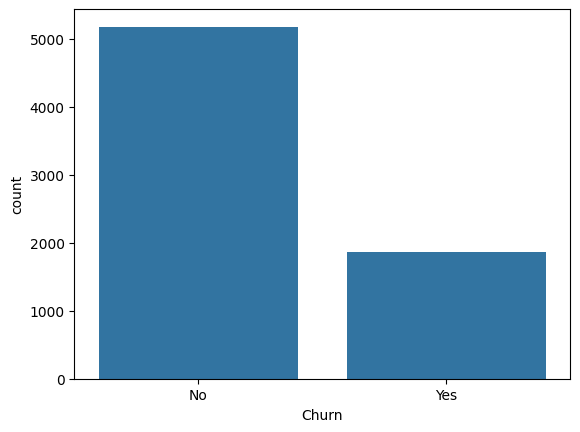

In [7]:
#Análise da variável target e sua visualização
df['Churn'].value_counts()
df['Churn'].value_counts(normalize = True) * 100 #Percentual
sns.countplot(x = 'Churn', data = df)

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64
Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64


<Axes: xlabel='Churn', ylabel='tenure'>

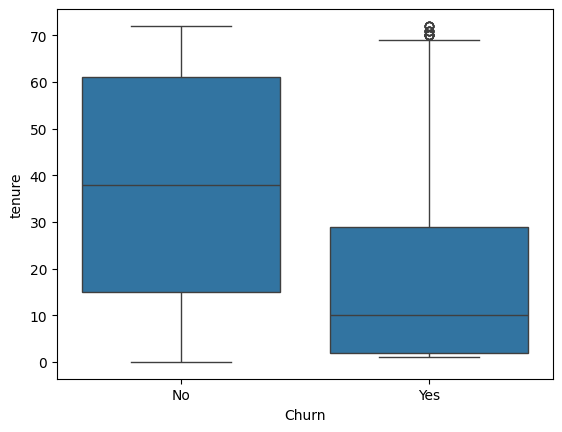

In [ ]:
#entender a relação do tenure com o churn e visualizar a distribuição do tenure para os clientes que churnaram e os que não churnaram
#devemos entender que a linha do meio é a mediana, os limites da caixa são o primeiro e terceiro quartil, e os pontos fora da caixa são os outliers

media = df.groupby('Churn')['tenure'].mean()
print(media)
median = df.groupby('Churn')['tenure'].median()
print(median)
sns.boxplot(x = 'Churn', y = 'tenure', data = df)


<Axes: xlabel='tenure_group', ylabel='count'>

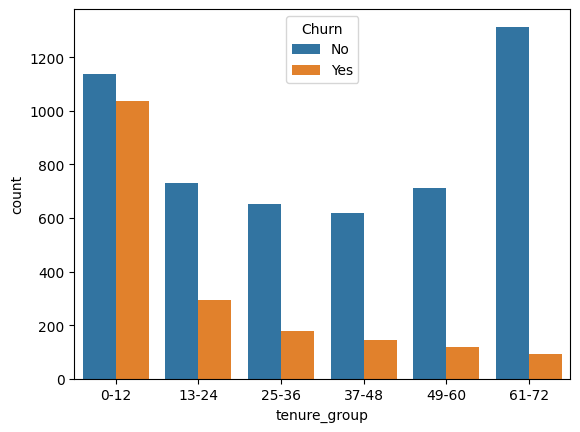

In [ ]:
#criando as bins para o tenure(importante para entender a distribuição do tenure e sua relação com o churn, além de facilitar a visualização e análise dos dados)
#fazemos essa parte para categorizar ela, o que pode ser importante para entender a relação do tenure com o churn, além de facilitar a visualização e análise dos dados, já que o tenure é uma variável numérica contínua, e categorizar ela pode ajudar a identificar padrões e tendências na relação entre o tenure e o churn.
df['tenure_group'] = pd.cut(df['tenure'], bins = [0, 12, 24, 36, 48, 60, 72], labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-72'])
sns.countplot(x = 'tenure_group', hue = 'Churn', data = df)

Churn                No        Yes
tenure_group                      
0-12          52.321839  47.678161
13-24         71.289062  28.710938
25-36         78.365385  21.634615
37-48         80.971129  19.028871
49-60         85.576923  14.423077
61-72         93.390192   6.609808


<Axes: xlabel='tenure_group', ylabel='count'>

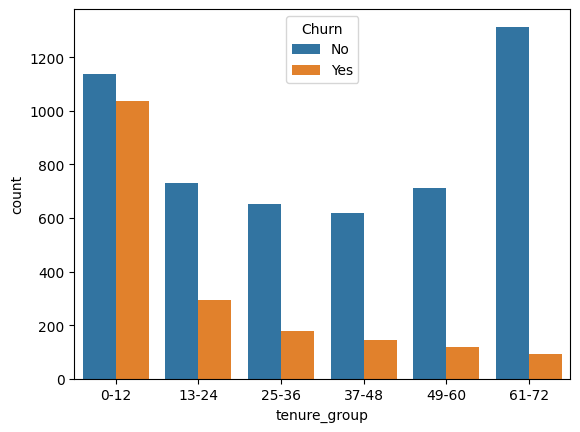

In [12]:
#avaliando a relação do tenure com o churn(importante para entender a relação do tenure com o churn e identificar quais grupos de tenure têm maior percentual de churn, o que pode ajudar a direcionar estratégias de retenção de clientes)
crosstab = pd.crosstab(df['tenure_group'], df['Churn'], normalize = 'index') * 100 #verificando o percentual de churn por grupo de tenure
print (crosstab)
sns.countplot(x = 'tenure_group', hue = 'Churn', data = df) #visualizando a relação do tenure com o churn

In [ ]:
#Aqui percebemos que clientes que tem 0-12 meses de tenure tem um percentual de churn muito alto, o que pode indicar que esses clientes estão insatisfeitos ou não estão encontrando valor no serviço, o que pode ser um ponto de atenção para a empresa.

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


<Axes: xlabel='Contract', ylabel='count'>

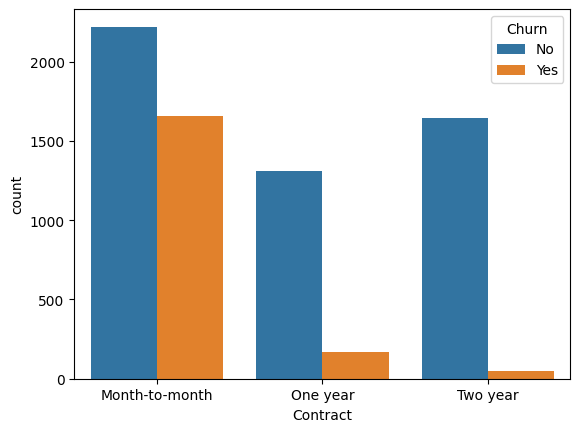

In [16]:
#realizando o crosstab da variável categorica Contract com a variável target Churn para entender a relação entre elas e identificar quais tipos de contrato têm maior percentual de churn, o que pode ajudar a direcionar estratégias de retenção de clientes

crosstab_contract = pd.crosstab(df['Contract'], df['Churn'], normalize = 'index') * 100
print(crosstab_contract)
sns.countplot(x = 'Contract', hue = 'Churn', data = df)


In [17]:
#aqui podemos ver que o percentual de churn é maior para clientes com contrato mensal, o que pode indicar que esses clientes estão mais propensos a cancelar o serviço, possivelmente devido à falta de compromisso a longo prazo, o que pode ser um ponto de atenção para a empresa.

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64 Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64


<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

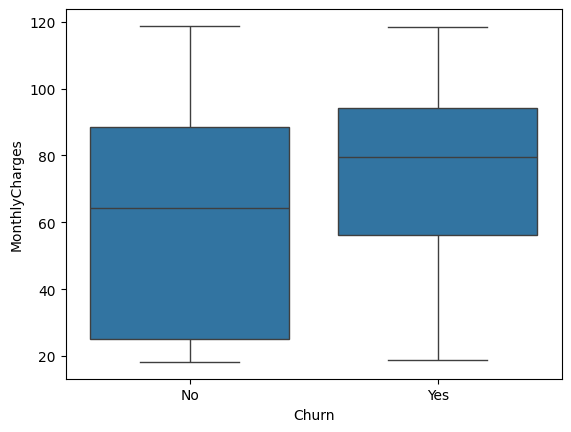

In [20]:
#realizando a mesma análise para a variável MonthlyCharges, que é uma variável numérica importante para entender a relação do valor gasto mensalmente com o churn
media_monthly = df.groupby('Churn')['MonthlyCharges'].mean()
median_monthly = df.groupby('Churn')['MonthlyCharges'].median()
print(media_monthly,median_monthly)
sns.boxplot(x = 'Churn', y = 'MonthlyCharges', data = df)

Churn                        No        Yes
MonthlyCharges_group                      
0-20                  91.158537   8.841463
21-40                 86.802030  13.197970
41-60                 74.444444  25.555556
61-80                 67.580535  32.419465
81-100                62.981859  37.018141


<Axes: xlabel='MonthlyCharges_group', ylabel='count'>

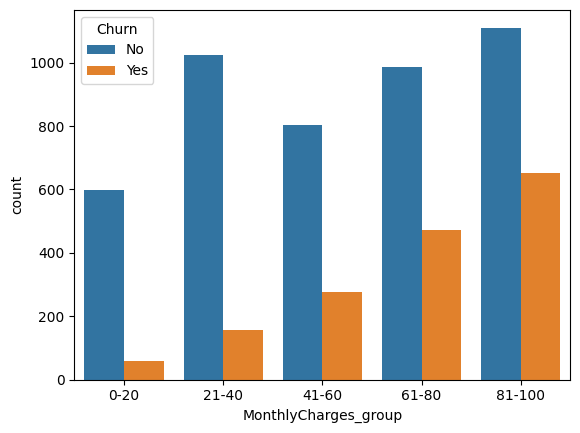

In [23]:
df['MonthlyCharges_group'] = pd.cut(df['MonthlyCharges'], bins = [0, 20, 40, 60, 80, 100], labels= ['0-20', '21-40', '41-60', '61-80', '81-100'])
crosstab_monthly = pd.crosstab(df['MonthlyCharges_group'], df['Churn'], normalize = 'index') * 100
print(crosstab_monthly)
sns.countplot(x = 'MonthlyCharges_group', hue = 'Churn', data = df)


In [24]:
#Isso mostra que o percentual de churns vai aumentando conforme o valor cobrado mensalmente aumenta, o que pode indicar que clientes que gastam mais mensalmente estão mais propensos a cancelar o serviço, possivelmente devido à percepção de que o custo é alto em relação ao valor recebido, o que pode ser um ponto de atenção para a empresa.

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


<Axes: xlabel='InternetService', ylabel='count'>

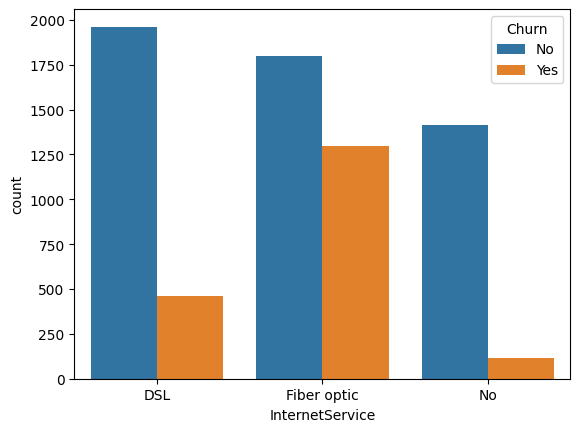

In [25]:
#realizando a mesma análise para a variável InternetService, que é uma variável categórica importante para entender a relação do tipo de serviço de internet com o churn
crosstab_InternetService = pd.crosstab(df['InternetService'], df['Churn'], normalize = 'index') * 100
print(crosstab_InternetService)
sns.countplot(x = 'InternetService', hue = 'Churn', data = df)


In [ ]:
#isso mostra que o percentual de churn é maior para clientes que tem serviço de internet do tipo Fiber optic, o que pode indicar que esses clientes estão mais propensos a cancelar o serviço, possivelmente devido à percepção de que o serviço de internet é instável ou de baixa qualidade, o que pode ser um ponto de atenção para a empresa.

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


<Axes: xlabel='PaymentMethod', ylabel='count'>

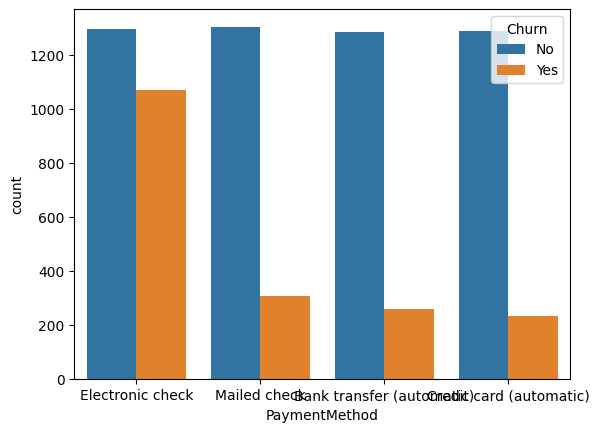

In [26]:
#realizando a mesma análise para a variável PaymentMethod, que é uma variável categórica importante para entender a relação do método de pagamento com o churn
crosstab_PaymentMethod = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize = 'index') * 100
print(crosstab_PaymentMethod)
sns.countplot(x = 'PaymentMethod', hue = 'Churn', data = df)


In [27]:
#Isso mostra que o percentual de churn é discrepantemente maior quando o método de pagamento é eletronic check, o que pode indicar que clientes que utilizam esse método de pagamento estão mais propensos a cancelar o serviço, possivelmente devido à percepção de que esse método é menos seguro ou menos conveniente, o que pode ser um ponto de atenção para a empresa.

Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


<Axes: xlabel='TechSupport', ylabel='count'>

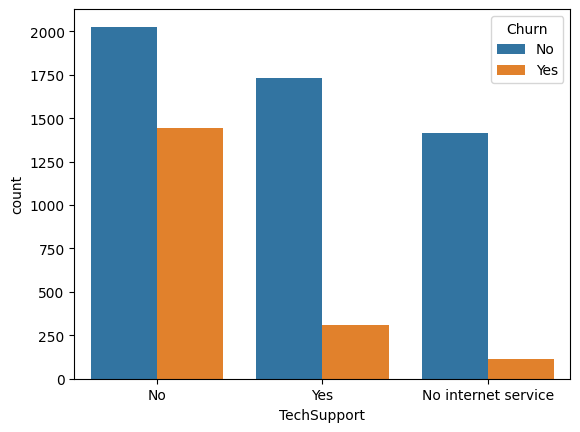

In [29]:
#Realizando a análise para a variável TechSupport, que é uma variável categórica importante para entender a relação do suporte técnico com o churn
crosstab_TechSupport = pd.crosstab(df['TechSupport'], df['Churn'], normalize = 'index') * 100
print(crosstab_TechSupport)
sns.countplot(x = 'TechSupport', hue = 'Churn', data= df)

In [30]:
#Visto isso é claro que pessoas sem techsupport tem um percentual de churn muito maior, o que pode indicar que a falta de suporte técnico é um fator importante para o churn, possivelmente devido à percepção de que a empresa não se importa com os clientes ou não oferece um serviço de qualidade, o que pode ser um ponto de atenção para a empresa.


Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194


<Axes: xlabel='OnlineSecurity', ylabel='count'>

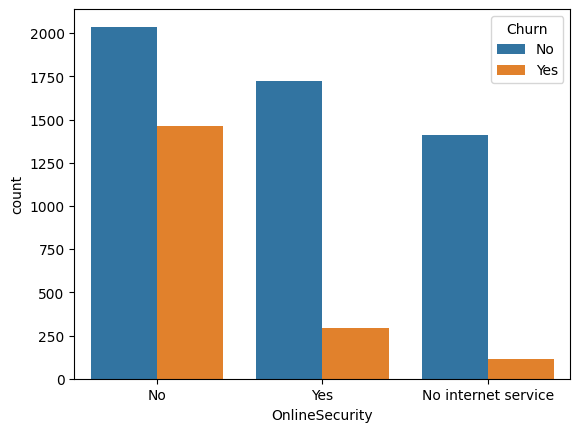

In [31]:
#realizando mesma análise para a variável OnlineSecurity, que é uma variável categórica importante para entender a relação da segurança online com o churn
crosstab_OnlineSecurity = pd.crosstab(df['OnlineSecurity'], df['Churn'], normalize = 'index')*100
print(crosstab_OnlineSecurity)
sns.countplot(x = 'OnlineSecurity', hue = 'Churn', data = df)

In [35]:
#Seguindo a linha de raciocínio, podemos perceber que clientes sem segurança online tem um percentual de churn muito maior, o que pode indicar que a falta de segurança online é um fator importante para o churn, possivelmente devido à percepção de que a empresa não se importa com os clientes ou não oferece um serviço de qualidade, o que pode ser um ponto de atenção para a empresa.

In [40]:
#Consertando o totalcharges estando object e não numérico, o que pode estar causando problemas na análise e visualização dos dados, além de impedir a criação de bins para essa variável, o que é importante para entender a distribuição do total charges e sua relação com o churn.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')


Churn
No     2555.344141
Yes    1531.796094
Name: TotalCharges, dtype: float64 Churn
No     1683.60
Yes     703.55
Name: TotalCharges, dtype: float64


<Axes: xlabel='Churn', ylabel='TotalCharges'>

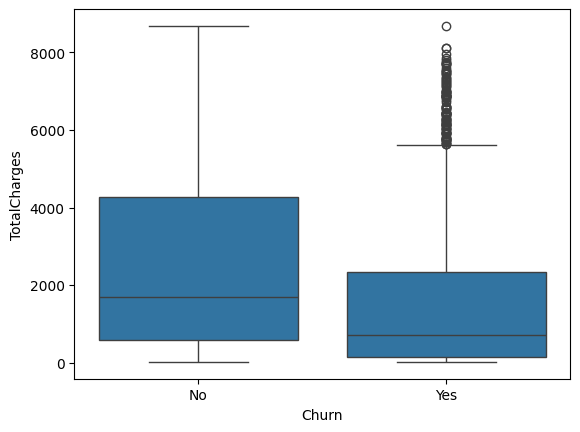

In [39]:
#Realizando a análise para a variável TotalCharges, que é uma variável numérica importante para entender a relação do valor total gasto com o churn
media_totalCharge = df.groupby('Churn')['TotalCharges'].mean()
median_totalcharges = df.groupby('Churn')['TotalCharges'].median()
print(media_totalCharge, median_totalcharges)
sns.boxplot(x = 'Churn', y = 'TotalCharges', data = df)


Churn                      No        Yes
TotalCharges_group                      
0-1000              63.014172  36.985828
1001-2000           79.033515  20.966485
2001-3000           72.392638  27.607362
3001-4000           80.755396  19.244604
4001-5000           83.235867  16.764133


<Axes: xlabel='TotalCharges_group', ylabel='count'>

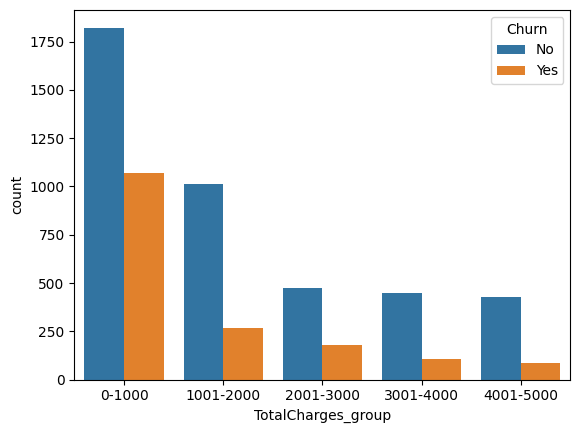

In [41]:
df['TotalCharges_group'] = pd.cut(df['TotalCharges'], bins = [0, 1000, 2000, 3000, 4000, 5000], labels = ['0-1000', '1001-2000', '2001-3000', '3001-4000', '4001-5000'])
crosstab_totalcharges = pd.crosstab(df['TotalCharges_group'], df ['Churn'], normalize = 'index') * 100
print(crosstab_totalcharges)
sns.countplot(x = 'TotalCharges_group', hue = 'Churn', data = df)

In [ ]:
#ao ver o gráfico percebemos que clientes com total charges entre 0 - 1000 tem um percentual levemente maior, o que pode indicar que clientes que gastam menos no total estão mais propensos a cancelar o serviço, possivelmente devido à percepção de que o valor gasto é baixo em relação ao valor recebido, o que pode ser um ponto de atenção para a empresa.